# **Models Comparison**

This final notebook brings together all five models developed across the project:

* the Neural-Network-based architectures (**BiLSTM** and **ULMFiT**);
* the Transformer-based (**DistilBERT**,
**RoBERTa**, and **DeBERTa-v3**).

What we do is comparing them directly on the same held-out test set.

The previous notebooks evaluated each family in isolation. The goal here is a single, fair
comparison along two dimensions that together determine which model is suitable for deployment:

1. **Predictive quality**: macro F1 (the headline metric for this imbalanced task), macro
precision and recall, and the F1 on the two minority classes (*Conspiratorial* and
*Critical/Skeptical*), which are the hardest and most informative.
2. **Computational cost**: the CPU inference latency per tweet and the model's size on disk,
which determine whether a model is practical to serve according to the user intent.

All quality metrics are recomputed uniformly from each model's saved test-set probabilities
(`probs_*.npy`), using the same functions and the same labels for every model. This guarantees
the numbers are directly comparable and not affected by differences in how each notebook
originally reported them. Latency and size are summarised in two final artifacts: a trade-off
chart and a comparison table.

In [ ]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import f1_score, precision_score, recall_score
import torch
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from fastai.text.all import load_learner
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
np.random.seed(SEED)

## **1. Set Up**

> **`FORCE_REMEASURE`** switch. Following the same display-first principle used throughout the project, latency and model size
are measured once and cached to `results/latency_cpu.json`.

With:

* `FORCE_REMEASURE = False` (default), the notebook loads the cached measurements and runs
instantly, without loading any of the large model files. This is the normal mode and works on any machine.
* `FORCE_REMEASURE = True`, the notebook re-measures latency by loading all five models on CPU and timing single-tweet inference. This requires the model files to be available and a CPU runtime, and overwrites the cached file.

> The quality metrics are always recomputed from the small `probs_*.npy` files, so they are
produced live on every run regardless of this switch.

In [ ]:
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/ARTEMIS_Sentiment_Analysis'
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

SPLITS_DIR  = os.path.join(PROJECT_ROOT, 'data', 'splits')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
BILSTM_RES  = os.path.join(PROJECT_ROOT, 'results', 'bilstm')
ULMFIT_RES  = os.path.join(PROJECT_ROOT, 'results', 'ulmfit')
TRANSF_RES  = os.path.join(PROJECT_ROOT, 'results', 'transformers')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
LATENCY_PATH = os.path.join(RESULTS_DIR, 'latency_cpu.json')

# Latency/size measured live only when True; otherwise loaded from JSON.
FORCE_REMEASURE = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Computing the Quality Metrics and Measuring Inference Latency**

This step loads the frozen test split and the shared label encoder, then computes the quality
metrics for all five models from their saved test-set probabilities (`probs_*.npy`).

Two points make the comparison fair. First, every model is evaluated on the same held-out test set and the same label encoder used throughout the project, so the class indices and the ground-truth labels are identical for all of them. Second, the metrics are recomputed from the saved probabilities rather than read from each notebook's summary files: each model's
prediction is taken as the argmax of its probability array, and macro F1, macro precision, macro
recall, and the F1 of the two minority classes are computed with the same functions for every
model.

This is possible because the predictions were generated and saved during the earlier notebooks, each in its own framework (Keras for the BiLSTM, fastai for ULMFiT, Hugging Face for the
Transformers) and stored as plain probability arrays. Reusing those arrays means this quality
comparison depends only on NumPy and scikit-learn: it loads none of the original frameworks and
none of the large model files, so it runs on any machine, including a fresh clone without the
weights. The length assertion confirms each probability array is aligned to the test set before
any metric is computed.

In [ ]:
test_df = pd.read_csv(os.path.join(SPLITS_DIR, 'test_split.csv'))
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)
test_df['label_enc'] = label_encoder.transform(test_df['label'])
y_true = test_df['label_enc'].values
target_names = list(label_encoder.classes_)

MODELS = [
    {'name': 'BiLSTM',     'probs': os.path.join(BILSTM_RES, 'probs_bilstm.npy')},
    {'name': 'ULMFiT',     'probs': os.path.join(ULMFIT_RES, 'probs_ulmfit.npy')},
    {'name': 'DistilBERT', 'probs': os.path.join(TRANSF_RES, 'probs_distilbert.npy')},
    {'name': 'RoBERTa',    'probs': os.path.join(TRANSF_RES, 'probs_roberta.npy')},
    {'name': 'DeBERTa-v3', 'probs': os.path.join(TRANSF_RES, 'probs_deberta.npy')},
]
CONSPIR  = target_names.index('Conspiratorial')
CRITICAL = target_names.index('Critical/Skeptical')

rows = []
for m in MODELS:
    preds = np.load(m['probs']).argmax(axis=1)
    assert len(preds) == len(y_true), f"{m['name']}: length mismatch"
    pcf1 = f1_score(y_true, preds, average=None, zero_division=0)
    rows.append({
        'Model':                 m['name'],
        'Macro F1':              round(f1_score(y_true, preds, average='macro', zero_division=0), 4),
        'Macro Precision':       round(precision_score(y_true, preds, average='macro', zero_division=0), 4),
        'Macro Recall':          round(recall_score(y_true, preds, average='macro', zero_division=0), 4),
        'Conspiratorial F1':     round(pcf1[CONSPIR], 4),
        'Critical/Skeptical F1': round(pcf1[CRITICAL], 4),
    })
metrics_df = pd.DataFrame(rows)

Quality alone does not determine which model is suitable for deployment; the cost of running it
matters too. This step measures, for each model, the CPU inference latency for a single tweet
and the size of the model on disk.

Unlike the quality metrics, which are recomputed from saved probabilities and need no frameworks, latency can only be measured by actually running each model. The code therefore loads each one
in its native framework (Keras, fastai, Hugging Face) and times the full single-tweet path:
tokenization plus the forward pass, with batch size 1, on CPU. This reflects the realistic cost
of one live prediction in an interactive application. A few warm-up predictions are run and discarded first, since the first inference is always slower due to lazy initialization, and the reported value is the average over the remaining tweets.

Because loading all five models is expensive, the measurement follows the same display-first
principle used throughout the project. When `FORCE_REMEASURE = False` (default), the cell simply
loads the cached results from `results/latency_cpu.json` and runs instantly, without touching the
model files. When `FORCE_REMEASURE = True`, it re-runs the full measurement and overwrites the
cache.

A note on the latency figures: they are not pure measures of each architecture's computational
speed. Three factors affect them:

1. Fixed-length padding: The recurrent models process every tweet padded to 60 tokens, doing
the same work regardless of the tweet's actual length, while the Transformers process each tweet
at its real length. This slightly penalises the recurrent models.

2. Framework overhead: Each latency is the end-to-end time through the model's native library
(Keras, fastai, Hugging Face), including tokenization and output decoding. This overhead is
substantial for fastai's `predict`, so ULMFiT's figure largely reflects framework cost rather
than the model's computation.

3. Hardware dependence: Absolute values depend on the CPU and vary between runs, so only the
relative ordering between models is meaningful.

The latency figures should therefore be read as a realistic but approximate measure of deployment
cost through each framework, useful for ranking the models by practical speed rather than as
exact timings.

> **Note**: set `FORCE_MEASURE = True` to compute the latency for each model.

In [ ]:
BILSTM_H5      = os.path.join(MODELS_DIR, 'bilstm', 'BiLSTM_sd0.2_rd0.2_u32_lr0.0005.h5')
TOKENIZER_PKL  = os.path.join(MODELS_DIR, 'tokenizer.pkl')
ULMFIT_PKL     = os.path.join(MODELS_DIR, 'ulmfit', 'ulmfit_classifier.pkl')
DISTILBERT_DIR = os.path.join(MODELS_DIR, 'transformers', 'distilbert')
ROBERTA_DIR    = os.path.join(MODELS_DIR, 'transformers', 'roberta')
DEBERTA_DIR    = os.path.join(MODELS_DIR, 'transformers', 'deberta')

MAX_LEN_BILSTM = 60
N_LATENCY = 100
N_WARMUP  = 10

def dir_size_mb(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / 1e6
    total = sum(os.path.getsize(os.path.join(r, f))
                for r, _, fs in os.walk(path) for f in fs)
    return total / 1e6

def time_single(predict_fn, texts):
    for t in texts[:N_WARMUP]:
        predict_fn(t)
    start = time.perf_counter()
    for t in texts:
        predict_fn(t)
    return ((time.perf_counter() - start) / len(texts)) * 1000

if os.path.exists(LATENCY_PATH) and not FORCE_REMEASURE:
    with open(LATENCY_PATH) as f:
        latency_data = json.load(f)
else:

    torch.set_num_threads(os.cpu_count())
    sample_texts = test_df['text'].astype(str).tolist()[:N_LATENCY]
    latency_data = {}

    with open(TOKENIZER_PKL, 'rb') as f:
        keras_tok = pickle.load(f)
    bilstm = load_model(BILSTM_H5)
    def predict_bilstm(text):
        seq = keras_tok.texts_to_sequences([text])
        pad = pad_sequences(seq, maxlen=MAX_LEN_BILSTM, padding='post', truncating='post')
        return bilstm.predict(pad, verbose=0)
    latency_data['BiLSTM'] = {'latency_ms': round(time_single(predict_bilstm, sample_texts), 2),
                              'size_mb':    round(dir_size_mb(BILSTM_H5), 1)}

    ulmfit = load_learner(ULMFIT_PKL, cpu=True)
    latency_data['ULMFiT'] = {'latency_ms': round(time_single(lambda t: ulmfit.predict(t), sample_texts), 2),
                              'size_mb':    round(dir_size_mb(ULMFIT_PKL), 1)}

    for name, mdir in [('DistilBERT', DISTILBERT_DIR), ('RoBERTa', ROBERTA_DIR), ('DeBERTa-v3', DEBERTA_DIR)]:
        tok = AutoTokenizer.from_pretrained(mdir)
        mdl = AutoModelForSequenceClassification.from_pretrained(mdir).to('cpu').eval()
        def predict_tf(text, tok=tok, mdl=mdl):
            inp = tok(text, return_tensors='pt', truncation=True, max_length=64)
            with torch.no_grad():
                return mdl(**inp).logits
        latency_data[name] = {'latency_ms': round(time_single(predict_tf, sample_texts), 2),
                              'size_mb':    round(dir_size_mb(mdir), 1)}

    with open(LATENCY_PATH, 'w') as f:
        json.dump(latency_data, f, indent=2)

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


## **3. Final Comparison**

The table below collects, for all five models, the quality metrics (macro F1, macro precision,
macro recall, and the F1 of the two minority classes) alongside the two cost metrics (CPU latency
and model size). It is the single reference summarising the entire project, and supports the
choice of a model for deployment by showing quality and cost side by side. Models are ordered by macro F1.

In [ ]:
table = metrics_df.copy()
table['CPU latency (ms)'] = table['Model'].map(lambda n: latency_data[n]['latency_ms'])
table['Size (MB)']        = table['Model'].map(lambda n: latency_data[n]['size_mb'])

table = table[['Model', 'Macro F1', 'Macro Precision', 'Macro Recall',
               'Conspiratorial F1', 'Critical/Skeptical F1',
               'CPU latency (ms)', 'Size (MB)']]
table = table.sort_values('Macro F1', ascending=False).reset_index(drop=True)

higher_better = ['Macro F1', 'Macro Precision', 'Macro Recall',
                 'Conspiratorial F1', 'Critical/Skeptical F1']
lower_better  = ['CPU latency (ms)', 'Size (MB)']

(table.style
    .format({'Macro F1': '{:.4f}', 'Macro Precision': '{:.4f}', 'Macro Recall': '{:.4f}',
             'Conspiratorial F1': '{:.4f}', 'Critical/Skeptical F1': '{:.4f}',
             'CPU latency (ms)': '{:.1f}', 'Size (MB)': '{:.1f}'})
    .set_caption('Final Model Comparison')
    .hide(axis='index'))

Model,Macro F1,Macro Precision,Macro Recall,Conspiratorial F1,Critical/Skeptical F1,CPU latency (ms),Size (MB)
DeBERTa-v3,0.7698,0.7695,0.7823,0.6835,0.6581,721.1,748.9
RoBERTa,0.7665,0.7510,0.7877,0.7079,0.6577,225.0,502.0
DistilBERT,0.7063,0.6959,0.7206,0.6171,0.5662,108.6,268.8
ULMFiT,0.6653,0.6478,0.7137,0.5439,0.5169,345.7,134.0
BiLSTM,0.6598,0.6592,0.6689,0.5500,0.5172,252.7,14.9


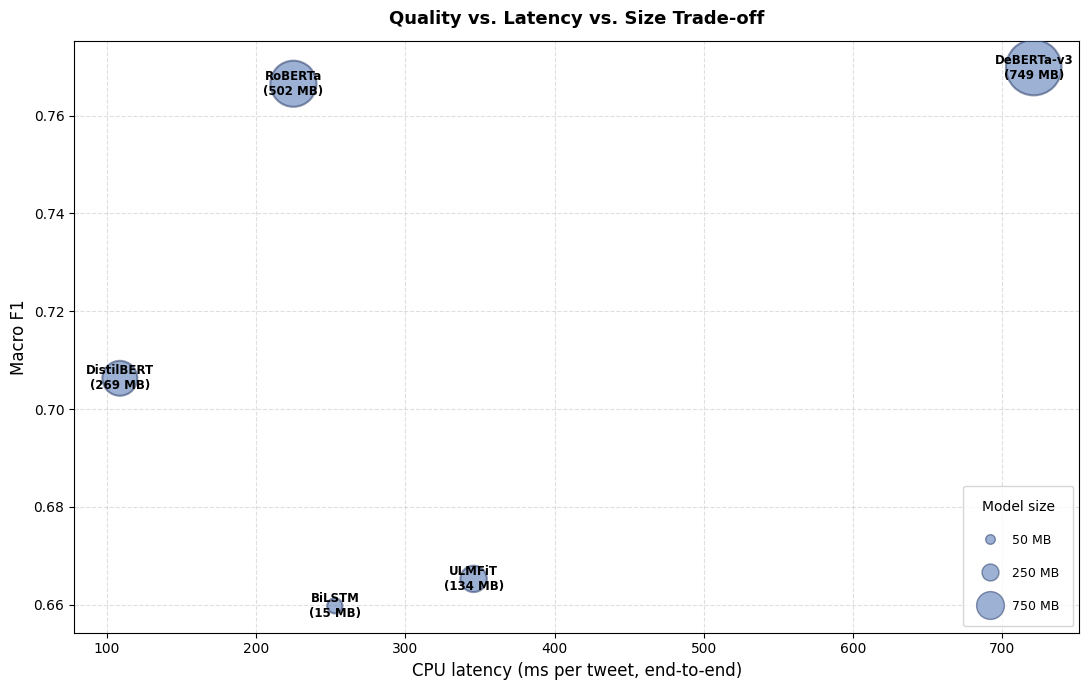

In [ ]:
plot_df = metrics_df.copy()
plot_df['Latency (ms)'] = plot_df['Model'].map(lambda n: latency_data[n]['latency_ms'])
plot_df['Size (MB)']    = plot_df['Model'].map(lambda n: latency_data[n]['size_mb'])

s_min, s_max = 120, 1600
sz = plot_df['Size (MB)']
bubble = s_min + (sz - sz.min()) / (sz.max() - sz.min()) * (s_max - s_min)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df['Latency (ms)'], plot_df['Macro F1'],
           s=bubble, color='#4C72B0', alpha=0.55,
           edgecolor='#2C3E6B', linewidth=1.5, zorder=3)

for _, r in plot_df.iterrows():
    ax.annotate(f"{r['Model']}\n({r['Size (MB)']:.0f} MB)",
                (r['Latency (ms)'], r['Macro F1']),
                ha='center', va='center', fontsize=8.5, fontweight='bold', zorder=4)

ax.set_xlabel('CPU latency (ms per tweet, end-to-end)', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Quality vs. Latency vs. Size Trade-off',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ref_sizes = [50, 250, 750]
ref_bubbles = [s_min + (rs - sz.min()) / (sz.max() - sz.min()) * (s_max - s_min) for rs in ref_sizes]
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0',
                  alpha=0.55, markeredgecolor='#2C3E6B',
                  markersize=(b**0.5/2), label=f'{rs} MB')
           for rs, b in zip(ref_sizes, ref_bubbles)]
ax.legend(handles=handles, title='Model size', labelspacing=1.6,
          borderpad=1.1, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

The table summarises the whole project in one view, and a clear two-tier structure emerges. The two recurrent models settle around a macro F1 of 0.66 (BiLSTM 0.660, ULMFiT 0.665), while all three Transformers move above it: DistilBERT to 0.706, and RoBERTa and DeBERTa-v3 to the top of the range at 0.766 and 0.770. The separation between the recurrent and Transformer groups is much
larger than any difference within either group, confirming that the architecture family, rather
than fine differences between individual models, is what drives quality on this task.

Almost all of that improvement comes from the two minority classes. Across the move from recurrent models to Transformers, *Conspiratorial* F1 rises from roughly 0.54 to 0.68–0.71 and *Critical/Skeptical* F1 from about 0.52 to 0.66, whereas the majority classes were already handled
well by every model. Because macro F1 weights all four classes equally, these minority gains are
the main reason the Transformers pull ahead, which is consistent with the central difficulty
identified throughout the project, the overlap between the two sceptical classes.

At the top of the table, RoBERTa and DeBERTa-v3 are effectively equivalent: their macro F1 differs
by only 0.003, well within run-to-run variation. They reach that level through slightly different
balances rather than one dominating the other, RoBERTa achieves the higher *Conspiratorial* F1
(0.708 against 0.684), while DeBERTa-v3 has marginally higher macro precision and the best
*Critical/Skeptical* F1. In practical terms they should be treated as two equally strong options.

The cost columns tell a different story from the quality ones, and this is where the comparison
becomes decisive. Quality and cost do not move together: DistilBERT is the fastest model at
108.6 ms and only mid-sized at 269 MB, yet it is clearly more accurate than both recurrent models.
DeBERTa-v3 obtains the highest macro F1, but at the greatest cost on both axes, the slowest at
721 ms, roughly three times RoBERTa, and the largest at 749 MB, in exchange for an advantage over
RoBERTa that is within noise. RoBERTa, by contrast, reaches almost the same quality as DeBERTa at
about a third of the latency and two-thirds of the size, making it the more efficient of the two
high-accuracy models.


## **4. Conclusions**

This project compared five models for sentiment classification of ARTEMIS II tweets, progressing
from recurrent neural networks to Transformer architectures, all evaluated on the same frozen
test set with macro F1 as the headline metric for this imbalanced, four-class task.

The two recurrent models established the baseline. The BiLSTM and the
transfer-learning ULMFiT reached almost identical performance, around a macro F1 of 0.66, and the
tweet-by-tweet analysis showed that their errors were largely the same: a shared residual of
short, ambiguous, or figurative tweets that neither could resolve. This ceiling, common to both models despite their different designs, was the motivation for moving to attention-based
architectures.

The three Transformers improved clearly on that baseline, and the gain was concentrated exactly
where the recurrent models were weakest, the two minority classes, *Conspiratorial* and
*Critical/Skeptical*, whose overlapping vocabulary had been identified as the central difficulty
of the dataset from the exploratory analysis onward. DistilBERT already exceeded the recurrent
ceiling (0.706), and RoBERTa and DeBERTa-v3 reached the top of the range (0.766 and 0.770),
effectively tied. The error-recovery analysis confirmed that the Transformers resolved more than
half of the cases both Neural-Network-based models had failed on, while the remaining residual driven by
irony, implication, and genuine label ambiguity proved largely irreducible, setting a ceiling
imposed by the data rather than by model capacity.

When cost is brought into the comparison, the picture sharpens. Quality and cost do not move
together: DistilBERT is the fastest model while also being more accurate than both recurrent
models, DeBERTa-v3 obtains the highest quality but at the greatest latency and size for an
advantage over RoBERTa that is within noise, and RoBERTa reaches nearly the same quality as
DeBERTa at a fraction of the cost. No single model is best on every dimension: DeBERTa-v3 leads on
overall quality, RoBERTa on *Conspiratorial* F1, DistilBERT on latency, and the BiLSTM on size.
It is worth noting that the recurrent models, although outperformed on quality, retain a genuine
advantage in footprint: the BiLSTM is several times smaller than any Transformer, which would make
it the appropriate choice in memory- or storage-constrained settings where the larger models
cannot be deployed.

The right choice therefore depends on the deployment priority, DistilBERT for the best balance of
speed and accuracy, RoBERTa for the best quality-per-cost where accuracy matters most, and
DeBERTa-v3 when maximum quality is required and cost is not a constraint.